In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist

print("CNN Assignment Started")

# =========================
# LOAD DATASET
# =========================

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training images shape:", x_train.shape)
print("Testing images shape:", x_test.shape)

# =========================
# CONVOLUTION LAYER
# =========================

class ConvLayer:
    def __init__(self, num_filters):
        self.num_filters = num_filters

        # 3x3 filters
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def iterate_regions(self, image):
        h, w = image.shape

        for i in range(h - 2):
            for j in range(w - 2):
                region = image[i:i+3, j:j+3]
                yield region, i, j

    def forward(self, input):
        self.last_input = input

        h, w = input.shape

        output = np.zeros((h - 2, w - 2, self.num_filters))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.sum(region * self.filters, axis=(1, 2))

        return output

    def backward(self, d_L_d_out, learning_rate):
        d_L_d_filters = np.zeros(self.filters.shape)

        for region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                d_L_d_filters[f] += d_L_d_out[i, j, f] * region

        # Update filters
        self.filters -= learning_rate * d_L_d_filters

        return None

# =========================
# MAXPOOL LAYER
# =========================

class MaxPool:
    def iterate_regions(self, image):
        h, w, num_filters = image.shape

        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):
                region = image[(i * 2):(i * 2 + 2),
                               (j * 2):(j * 2 + 2)]

                yield region, i, j

    def forward(self, input):
        self.last_input = input

        h, w, num_filters = input.shape

        output = np.zeros((h // 2, w // 2, num_filters))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.amax(region, axis=(0, 1))

        return output

    def backward(self, d_L_d_out):
        d_L_d_input = np.zeros(self.last_input.shape)

        for region, i, j in self.iterate_regions(self.last_input):
            h, w, f = region.shape

            amax = np.amax(region, axis=(0, 1))

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):

                        if region[i2, j2, f2] == amax[f2]:
                            d_L_d_input[i * 2 + i2,
                                        j * 2 + j2,
                                        f2] = d_L_d_out[i, j, f2]

        return d_L_d_input

# =========================
# SOFTMAX LAYER
# =========================

class Softmax:
    def __init__(self, input_len, nodes):
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
        self.last_input_shape = input.shape

        input = input.flatten()
        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals

        exp = np.exp(totals)
        return exp / np.sum(exp, axis=0)

    def backward(self, d_L_d_out, learning_rate):
        for i, gradient in enumerate(d_L_d_out):

            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals)

            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)

            d_t_d_w = self.last_input
            d_t_d_inputs = self.weights

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]

            d_L_d_b = d_L_d_t

            d_L_d_inputs = d_t_d_inputs @ d_L_d_t

            # Update weights and biases
            self.weights -= learning_rate * d_L_d_w
            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs.reshape(self.last_input_shape)

# =========================
# CNN MODEL
# =========================

conv = ConvLayer(8)
pool = MaxPool()
softmax = Softmax(13 * 13 * 8, 10)

# =========================
# FORWARD PASS
# =========================

def forward(image, label):
    out = conv.forward((image[:, :, 0]))
    out = pool.forward(out)
    out = softmax.forward(out)

    # Loss
    loss = -np.log(out[label])

    # Accuracy
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

# =========================
# TRAIN FUNCTION
# =========================

def train(image, label, lr=0.005):
    # Forward
    out, loss, acc = forward(image, label)

    # Initial gradient
    gradient = np.zeros(10)
    gradient[label] = -1 / out[label]

    # Backward
    gradient = softmax.backward(gradient, lr)
    gradient = pool.backward(gradient)
    conv.backward(gradient, lr)

    return loss, acc

# =========================
# TESTING
# =========================

print("\n--- TESTING ---\n")

loss = 0
num_correct = 0

for image, label in zip(x_test[:100], y_test[:100]):
    _, l, acc = forward(image, label)

    loss += l
    num_correct += acc

print("Test Loss:", loss / 100)
print("Test Accuracy:", num_correct, "%")

print("\nCNN Assignment Completed")

CNN Assignment Started
Training images shape: (60000, 28, 28, 1)
Testing images shape: (10000, 28, 28, 1)

--- TESTING ---

Test Loss: 2.3033521585671655
Test Accuracy: 2 %

CNN Assignment Completed


In [ ]:
# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
batch_losses_per_epoch = []
batch_accuracies_per_epoch = []

### Modified Training Loop

In [ ]:
print("\n--- TRAINING STARTED ---\n")

epochs = 3

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}")

    epoch_loss = 0
    epoch_num_correct = 0
    current_epoch_batch_losses = []
    current_epoch_batch_accuracies = []

    batch_loss_sum = 0
    batch_num_correct_sum = 0

    # Using a smaller subset for faster demonstration
    num_samples_to_train = 1000 # Adjust if you want to train on more data

    for i, (image, label) in enumerate(zip(x_train[:num_samples_to_train], y_train[:num_samples_to_train])):

        l, acc = train(image, label)

        batch_loss_sum += l
        batch_num_correct_sum += acc

        epoch_loss += l
        epoch_num_correct += acc

        if (i + 1) % 100 == 0:
            avg_batch_loss = batch_loss_sum / 100
            batch_accuracy = (batch_num_correct_sum / 100 * 100)
            print(
                f"[Step {i+1}] "
                f"Average Batch Loss: {avg_batch_loss:.3f} | "
                f"Batch Accuracy: {batch_accuracy:.2f}%"
            )
            current_epoch_batch_losses.append(avg_batch_loss)
            current_epoch_batch_accuracies.append(batch_accuracy)
            batch_loss_sum = 0
            batch_num_correct_sum = 0

    # Store epoch-level metrics
    train_losses.append(epoch_loss / num_samples_to_train)
    train_accuracies.append(epoch_num_correct / num_samples_to_train * 100)

    # Store batch-level metrics for the current epoch
    batch_losses_per_epoch.append(current_epoch_batch_losses)
    batch_accuracies_per_epoch.append(current_epoch_batch_accuracies)

    print(f"Epoch {epoch + 1} finished: Average Loss = {train_losses[-1]:.3f}, Accuracy = {train_accuracies[-1]:.2f}%\n")


--- TRAINING STARTED ---

Epoch 1
[Step 100] Average Batch Loss: 2.206 | Batch Accuracy: 22.00%
[Step 200] Average Batch Loss: 1.875 | Batch Accuracy: 39.00%
[Step 300] Average Batch Loss: 1.638 | Batch Accuracy: 43.00%
[Step 400] Average Batch Loss: 1.426 | Batch Accuracy: 50.00%
[Step 500] Average Batch Loss: 1.042 | Batch Accuracy: 67.00%
[Step 600] Average Batch Loss: 1.250 | Batch Accuracy: 56.00%
[Step 700] Average Batch Loss: 0.948 | Batch Accuracy: 70.00%
[Step 800] Average Batch Loss: 0.941 | Batch Accuracy: 64.00%
[Step 900] Average Batch Loss: 0.988 | Batch Accuracy: 66.00%
[Step 1000] Average Batch Loss: 1.065 | Batch Accuracy: 64.00%
Epoch 1 finished: Average Loss = 1.338, Accuracy = 54.10%

Epoch 2
[Step 100] Average Batch Loss: 0.794 | Batch Accuracy: 73.00%
[Step 200] Average Batch Loss: 0.769 | Batch Accuracy: 74.00%
[Step 300] Average Batch Loss: 1.054 | Batch Accuracy: 68.00%
[Step 400] Average Batch Loss: 0.935 | Batch Accuracy: 74.00%
[Step 500] Average Batch Loss

### Visualize Training Metrics


--- Visualizing Epoch 1 ---


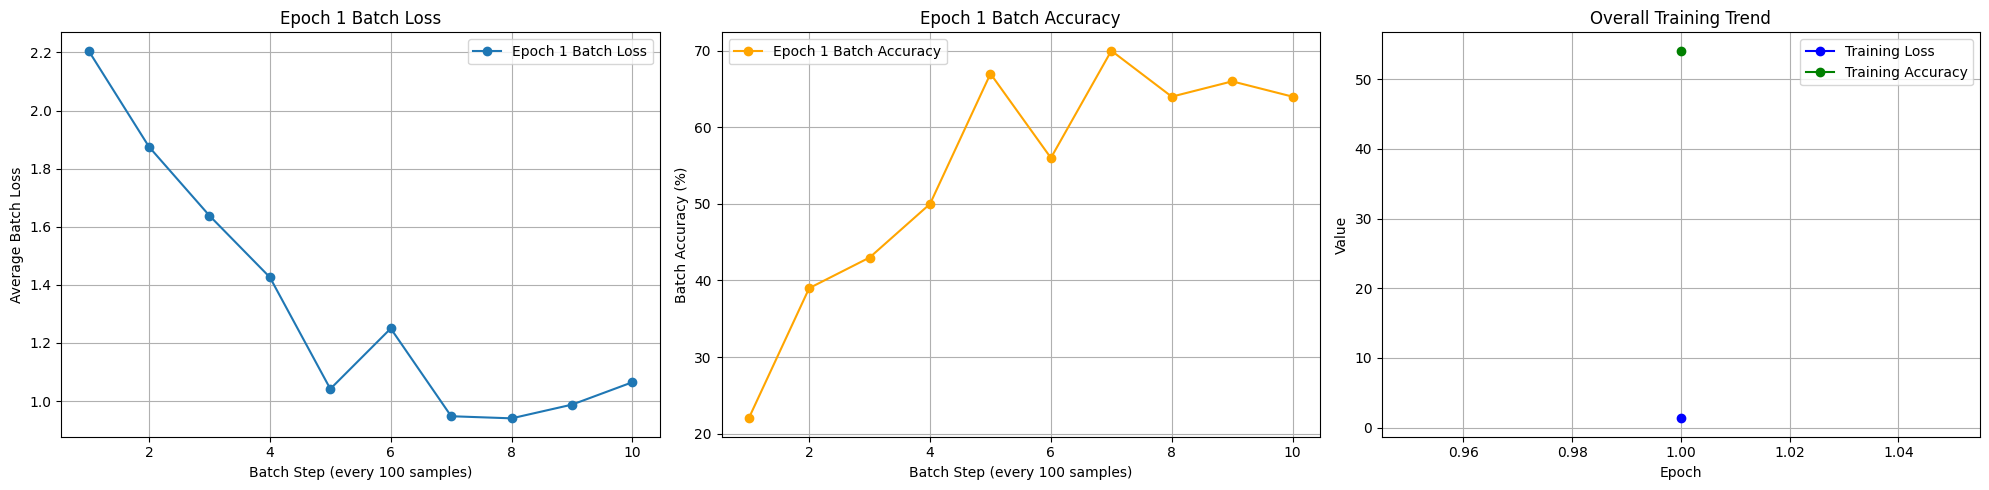


--- Visualizing Epoch 2 ---


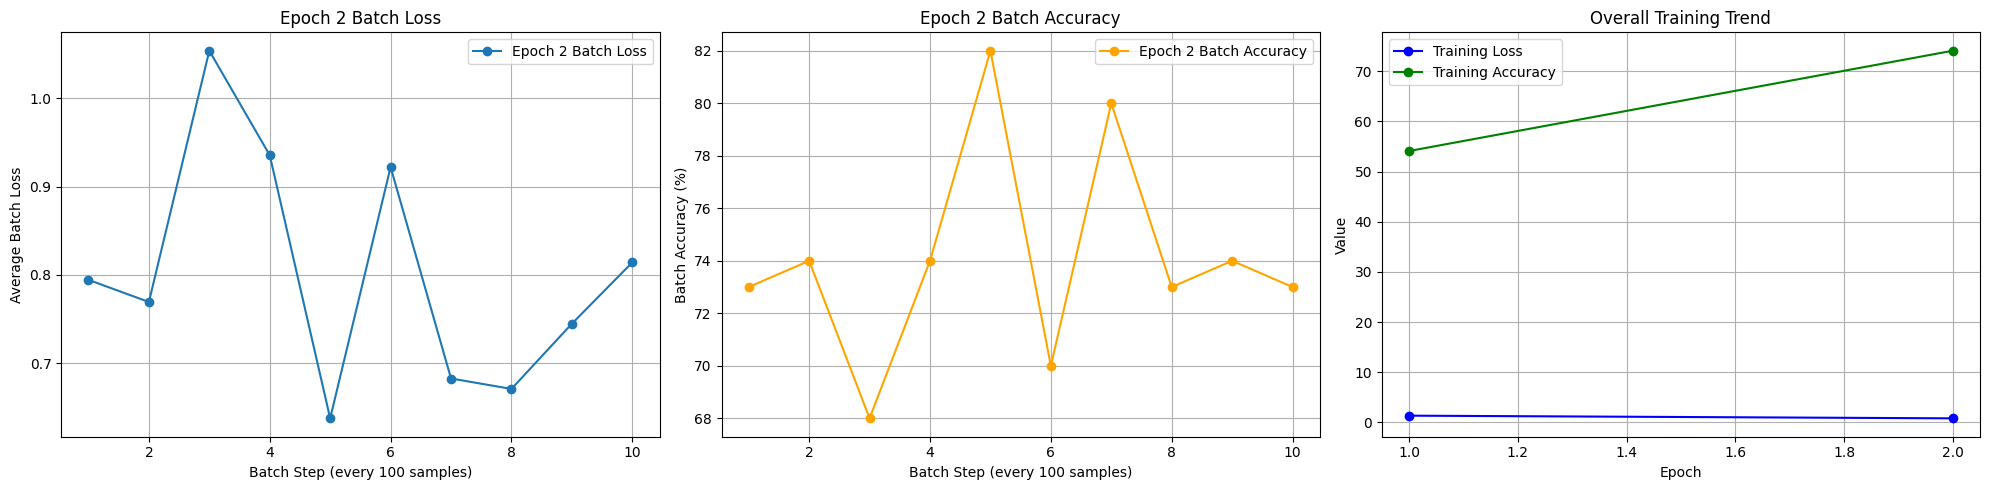


--- Visualizing Epoch 3 ---


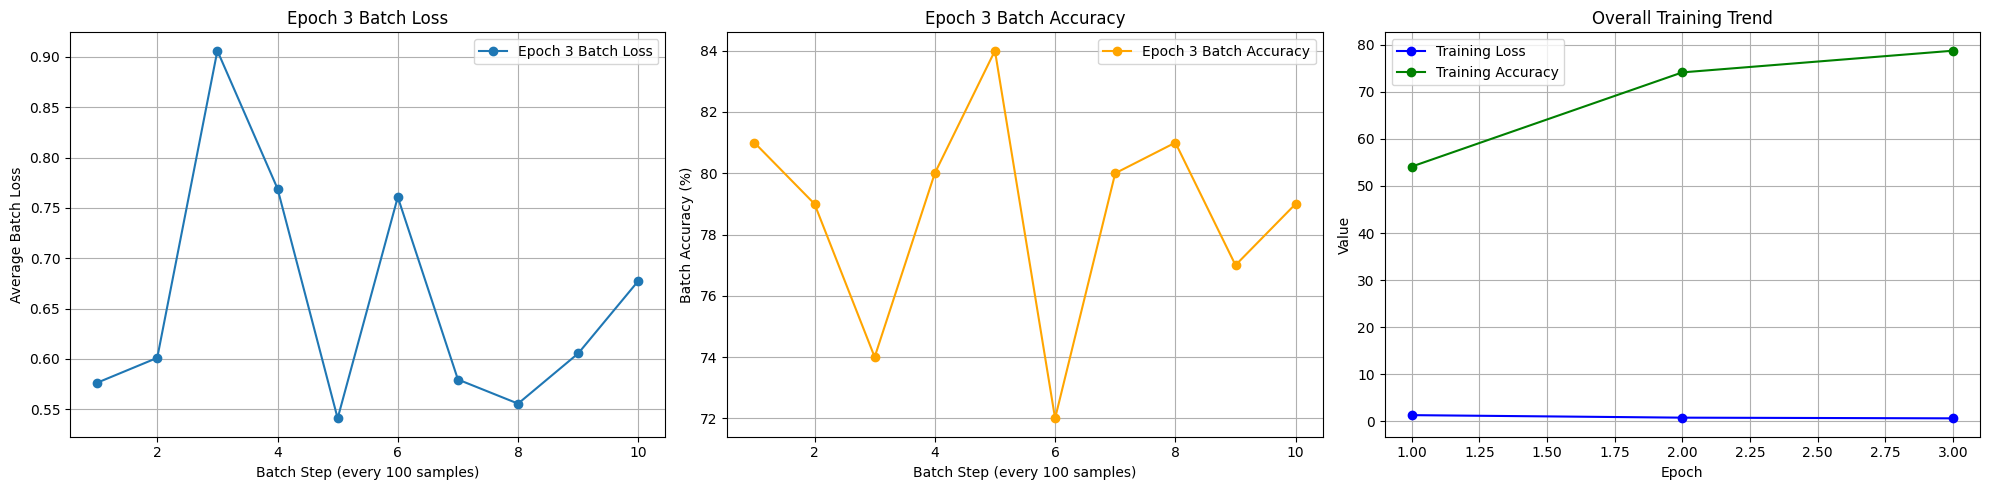

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

for epoch_idx in range(epochs):
    current_epoch = epoch_idx + 1
    print(f"\n--- Visualizing Epoch {current_epoch} ---")

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    # Plot 1: Batch Loss for the current epoch
    batch_steps = range(1, len(batch_losses_per_epoch[epoch_idx]) + 1)
    axs[0].plot(batch_steps, batch_losses_per_epoch[epoch_idx], label=f'Epoch {current_epoch} Batch Loss', marker='o', linestyle='-')
    axs[0].set_title(f'Epoch {current_epoch} Batch Loss')
    axs[0].set_xlabel('Batch Step (every 100 samples)')
    axs[0].set_ylabel('Average Batch Loss')
    axs[0].grid(True)
    axs[0].legend()

    # Plot 2: Batch Accuracy for the current epoch
    axs[1].plot(batch_steps, batch_accuracies_per_epoch[epoch_idx], label=f'Epoch {current_epoch} Batch Accuracy', marker='o', linestyle='-', color='orange')
    axs[1].set_title(f'Epoch {current_epoch} Batch Accuracy')
    axs[1].set_xlabel('Batch Step (every 100 samples)')
    axs[1].set_ylabel('Batch Accuracy (%)')
    axs[1].grid(True)
    axs[1].legend()

    # Plot 3: Overall Training Trend (Loss and Accuracy up to current epoch)
    axs[2].plot(epochs_range[:current_epoch], train_losses[:current_epoch], label='Training Loss', marker='o', color='blue')
    axs[2].plot(epochs_range[:current_epoch], train_accuracies[:current_epoch], label='Training Accuracy', marker='o', color='green')
    axs[2].set_title('Overall Training Trend')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Value')
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.show()